# Import data as dataframes

In [89]:
import pandas as pd
import numpy as np
import os

acsdata_path = "../data/processed/"

spectra_A_df = pd.read_csv(os.path.join(acsdata_path,"acs_a_clean_df.csv"), index_col="index")
spectra_A_df = spectra_A_df[spectra_A_df["preprocessing"] == "raw"]
spectra_S_df = pd.read_csv(os.path.join(acsdata_path,"acs_s_clean_df.csv"), index_col="index")
spectra_S_df = spectra_S_df[spectra_S_df["preprocessing"] == "raw"]

labdata_path = "../data/raw/3_laboratory_measurements"

lab_data = pd.read_csv(os.path.join(labdata_path, "sample_s01-s24.csv"))
lab_data["tss_mg_l"] = lab_data["ss_04u_mg_l"] + lab_data["ss_14u_mg_l"]
metadata = pd.read_csv(os.path.join(labdata_path, "sample_metadata.csv"))
lab_data = metadata.merge(lab_data)

spectra_A_df = lab_data.merge(spectra_A_df)
spectra_S_df = lab_data.merge(spectra_S_df)

sp_cols_A = spectra_A_df.columns[23:]
wav_A = np.array(sp_cols_A.astype("float"))

sp_cols_S = spectra_S_df.columns[23:]
wav_S = np.array(sp_cols_S.astype("float"))

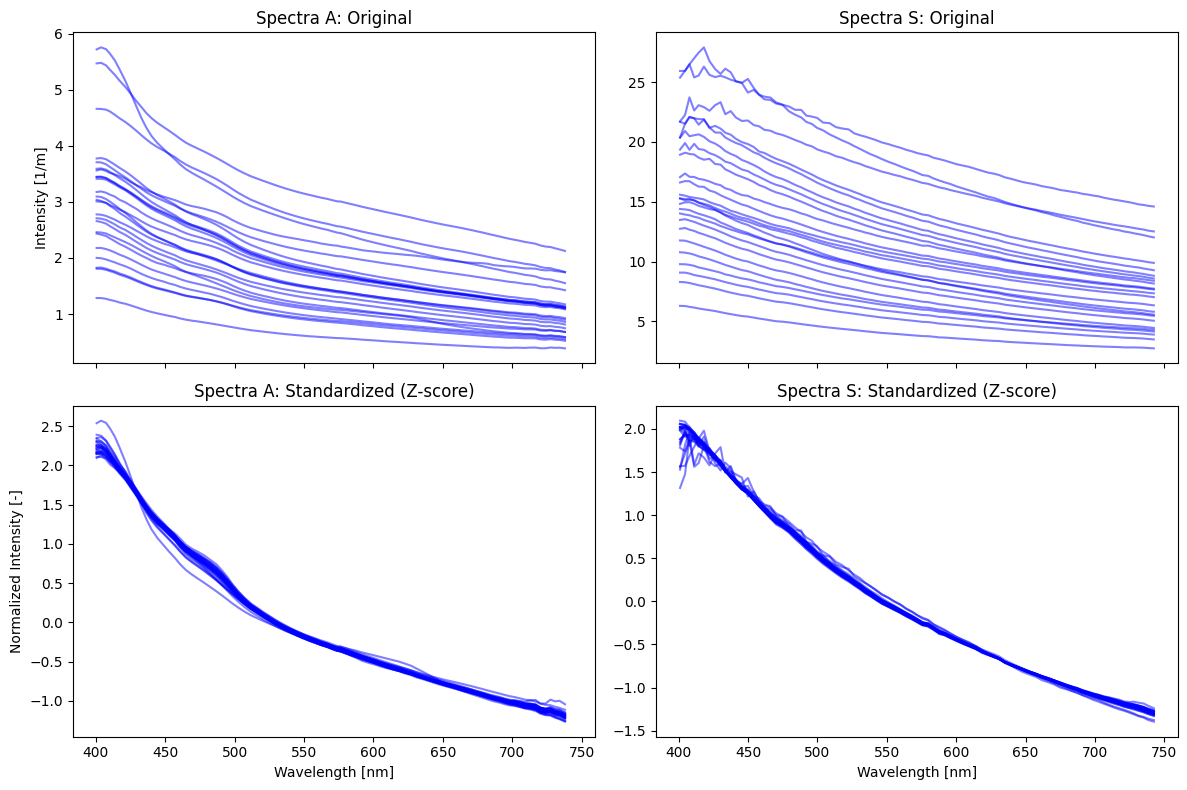

In [90]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, nrows=2, sharex=True, figsize = (12, 8))


for (i, sample_data) in spectra_A_df.iterrows():
    sp = sample_data[sp_cols_A]
    ax[0, 0].plot(wav_A, sp, color="blue", alpha=0.5)
    
    norm_sp = (sp-sp.mean())/sp.std()
    ax[1, 0].plot(wav_A, norm_sp, color="blue", alpha=0.5)
    
for (i, sample_data) in spectra_S_df.iterrows():
    sp = sample_data[sp_cols_S]
    ax[0, 1].plot(wav_S, sp, color="blue", alpha=0.5)
    
    norm_sp = (sp-sp.mean())/sp.std()
    ax[1, 1].plot(wav_S, norm_sp, color="blue", alpha=0.5)

# Adding Titles
ax[0, 0].set_title("Spectra A: Original")
ax[0, 1].set_title("Spectra S: Original")
ax[1, 0].set_title("Spectra A: Standardized (Z-score)")
ax[1, 1].set_title("Spectra S: Standardized (Z-score)")

# Adding Y-labels (Left side applies to the whole row usually, or label both)
ax[0, 0].set_ylabel("Intensity [1/m]")
ax[1, 0].set_ylabel("Normalized Intensity [-]")

# Adding X-labels (Bottom row only since sharex=True)
ax[1, 0].set_xlabel("Wavelength [nm]")
ax[1, 1].set_xlabel("Wavelength [nm]")

# Improve spacing between subplots
plt.tight_layout()
plt.show()

**Comment on the above plot:**
We see that the amplitute of the spectra is containing most information. Once corrected, the shape of all the raw spectra is very similar. Later, I will do a PCA analysis to see extrac the shape of the different components of the spectra, and their percentage of explained variance. 

# Scattering coeff power law fit and how it relates to turbidity

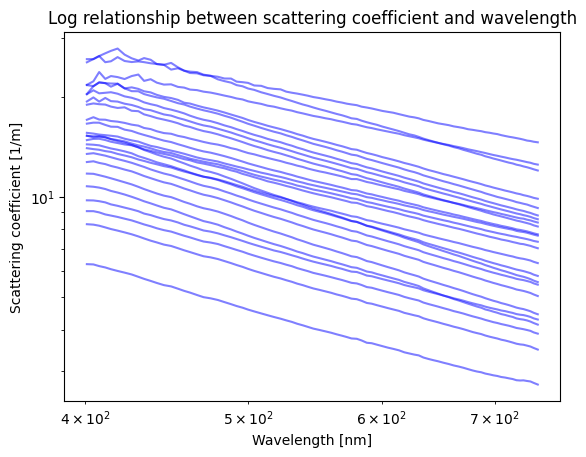

In [91]:
for (i, sample_data) in spectra_S_df.iterrows():
    plt.plot(wav_S, sample_data[sp_cols_S], color="blue", alpha=0.5)

plt.xscale("log"), 
plt.yscale("log")
plt.ylabel("Scattering coefficient [1/m]")
plt.xlabel("Wavelength [nm]")
plt.title("Log relationship between scattering coefficient and wavelength")
plt.show()

<>:34: SyntaxWarning:

invalid escape sequence '\l'

<>:34: SyntaxWarning:

invalid escape sequence '\l'

C:\Users\pierr\AppData\Local\Temp\ipykernel_6788\2359412981.py:34: SyntaxWarning:

invalid escape sequence '\l'



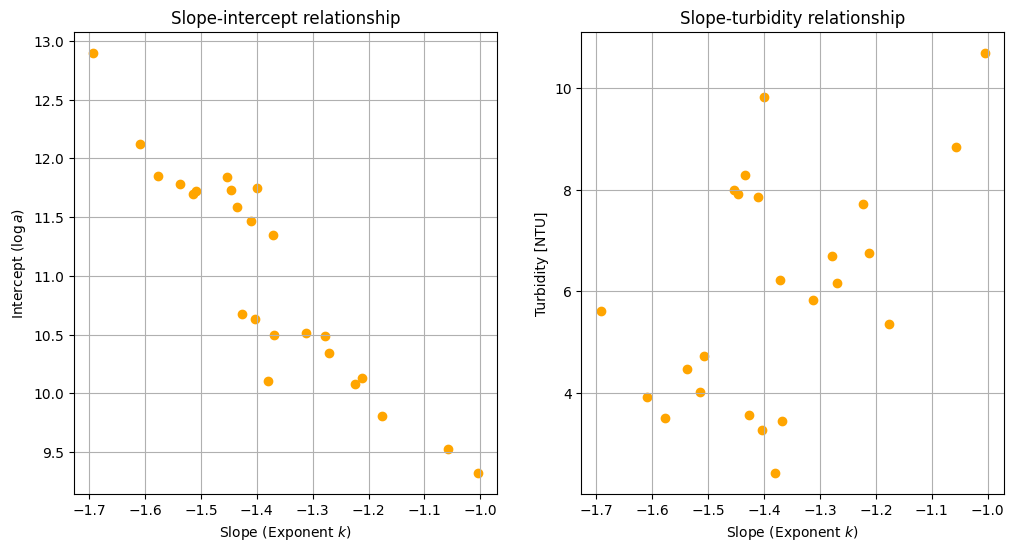

In [92]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

color_map = {
    "raw": "orange", 
    "04u": "blue", 
    "14u": "green" 
}

for (i, sample_data) in spectra_S_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        
        if "raw" in full_sample_name:
            color = color_map['raw']
            label="raw"
        elif "04u" in full_sample_name:
            color = color_map['04u']
            label="04u"
        elif "14u" in full_sample_name:
            color = color_map['14u']
            label="14u"

        
        y_values = sample_data[sp_cols_S].values.astype(float)
        slope, intercept = np.polyfit(np.log(wav_S), np.log(y_values), 1)
        turbidity = sample_data["tur_raw_ntu"]
        ax[0].scatter(slope, intercept, color=color, label=label)
        ax[1].scatter(slope, turbidity, color=color, label=label)
    except Exception as e:
        print(f"ERROR TYPE: {type(e).__name__}")
        print(f"ERROR MESSAGE: {e}")
    
ax[0].set_xlabel('Slope (Exponent $k$)')
ax[0].set_ylabel('Intercept ($\log a$)')
ax[0].set_title('Slope-intercept relationship')
ax[0].grid(True)
ax[1].set_xlabel('Slope (Exponent $k$)')
ax[1].set_ylabel('Turbidity [NTU]')
ax[1].set_title('Slope-turbidity relationship')
ax[1].grid(True)

plt.show()


In [93]:
slope_intercept_lst = []

for (i, sample_data) in spectra_S_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        y_values = sample_data[sp_cols_S].values.astype(float)
        
        # 1. Linear fit on log-log data: log(y) = slope * log(x) + intercept
        # Ensure values are positive before logging
        mask = (y_values > 0) & (wav_S > 0)
        slope, intercept = np.polyfit(np.log(wav_S[mask]), np.log(y_values[mask]), 1)
        
        
        slope_intercept_lst.append({
            "full_sample_name": full_sample_name,
            "slope": slope, 
            "intercept": intercept
        })

    except Exception as e:
        print(f"ERROR on {full_sample_name}: {type(e).__name__} - {e}")

spectra_S_df = pd.DataFrame(slope_intercept_lst).merge(spectra_S_df)


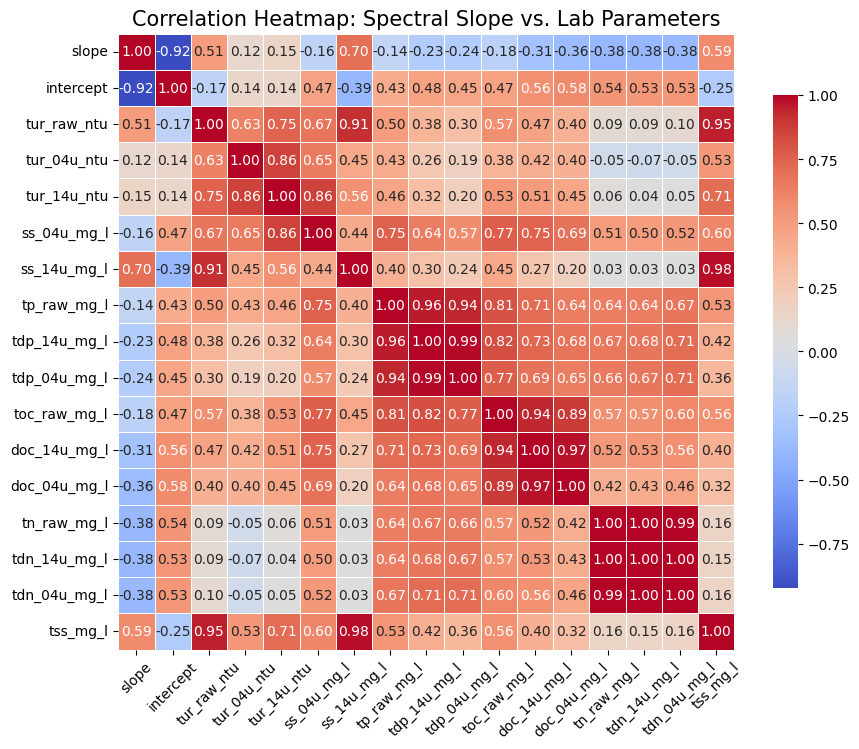

In [94]:

import seaborn as sns
import matplotlib.pyplot as plt

# Convert both slices to lists and add them together
cols_for_corr_analysis = list(spectra_S_df.columns[1:3]) + list(spectra_S_df.columns[9:24])

# 1. Calculate the correlation matrix
# We use .iloc[:, 1:] to ensure we only include numeric columns
corr_matrix = spectra_S_df[cols_for_corr_analysis].corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# 3. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,           # Show the correlation numbers in the cells
    cmap='coolwarm',      # Blue-to-Red color palette
    fmt=".2f",            # Format to 2 decimal places
    square=True,          # Make the cells square
    linewidths=0.5,       # Add small gaps between cells
    cbar_kws={"shrink": .8}
)

# 4. Final touches
plt.title('Correlation Heatmap: Spectral Slope vs. Lab Parameters', fontsize=15)
plt.xticks(rotation=45)
plt.show()

--- MLR Results ---
Intercept: -1.3971
         Feature  Coefficient
0    tur_raw_ntu    -0.002772
1    tur_04u_ntu     0.146958
2    tur_14u_ntu     0.004320
3    ss_04u_mg_l     0.016175
4    ss_14u_mg_l     0.017819
5    tp_raw_mg_l    -0.640239
6   tdp_14u_mg_l    -3.072354
7   tdp_04u_mg_l     3.364922
8   toc_raw_mg_l     0.000098
9   doc_14u_mg_l    -0.002092
10  doc_04u_mg_l    -0.006170
11   tn_raw_mg_l    -0.047649
12  tdn_14u_mg_l    -0.016996
13  tdn_04u_mg_l     0.070999
14      tss_mg_l     0.033995
R² Score: 0.919
RMSE: 0.0468


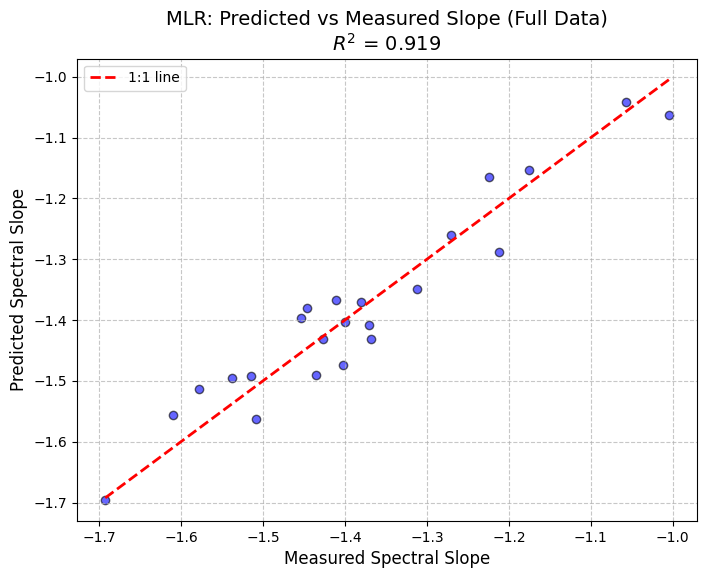

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target (y)
# Using 'toc' based on your previous dictionary keys
features = list(spectra_S_df.columns[9:24])

# Create a cleaned version of the dataframe
res_df_clean = spectra_S_df.dropna(subset=features+["slope"])

# Re-run the model using the cleaned data
X = res_df_clean[features]
y = res_df_clean['slope']

model = LinearRegression()
model.fit(X, y)

# 2. Initialize and Train the Model on the full dataset
model = LinearRegression()
model.fit(X, y)

# 3. Generate Predictions for the same dataset
y_pred = model.predict(X)

# 4. Calculate Fit Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 5. Display Coefficients and Intercept
print(f"--- MLR Results ---")
print(f"Intercept: {model.intercept_:.4f}")
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print(coeff_df)
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.4f}")

# 6. Parity Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="1:1 line")

plt.title(f'MLR: Predicted vs Measured Slope (Full Data)\n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel('Measured Spectral Slope', fontsize=12)
plt.ylabel('Predicted Spectral Slope', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Only two features

Top 2 Features Selected: ['ss_14u_mg_l', 'tss_mg_l']

--- Optimized MLR (Top 2) ---
Features: ['ss_14u_mg_l', 'tss_mg_l']
Intercept: -1.4483
ss_14u_mg_l Coefficient: 0.1699
tss_mg_l Coefficient: -0.1231
R² Score: 0.758


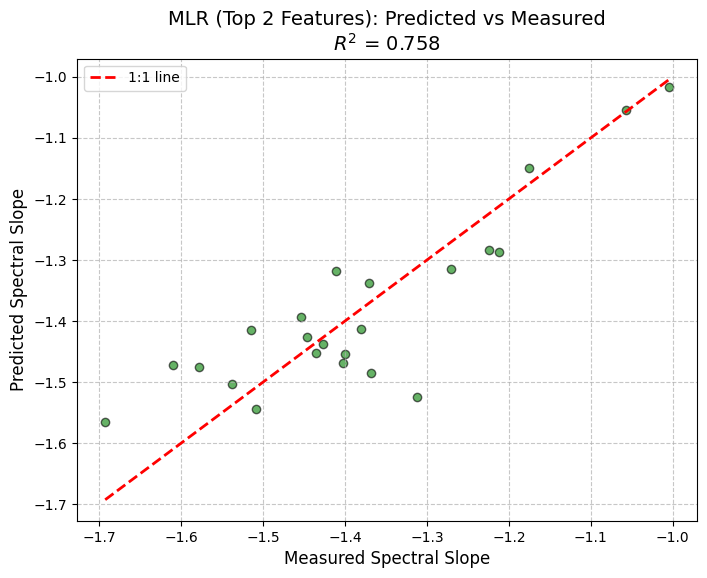

In [96]:
from sklearn.feature_selection import SelectKBest, f_regression

# 1. Identify the 2 best features
selector = SelectKBest(score_func=f_regression, k=2)
selector.fit(X, y)

# Get the names of the top 2 features
best_features = [features[i] for i in selector.get_support(indices=True)]
print(f"Top 2 Features Selected: {best_features}")

# 2. Re-fit the model using ONLY these two
X_best = res_df_clean[best_features]
model_best = LinearRegression()
model_best.fit(X_best, y)

y_pred_best = model_best.predict(X_best)

# 3. Calculate New Metrics
r2_best = r2_score(y, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y, y_pred_best))

# 4. Display Results
print(f"\n--- Optimized MLR (Top 2) ---")
print(f"Features: {best_features}")
print(f"Intercept: {model_best.intercept_:.4f}")
for feat, coef in zip(best_features, model_best.coef_):
    print(f"{feat} Coefficient: {coef:.4f}")
print(f"R² Score: {r2_best:.3f}")

# 5. Parity Plot for the 2-Feature Model
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_best, color='green', alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="1:1 line")

plt.title(f'MLR (Top 2 Features): Predicted vs Measured\n$R^2$ = {r2_best:.3f}', fontsize=14)
plt.xlabel('Measured Spectral Slope', fontsize=12)
plt.ylabel('Predicted Spectral Slope', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# PCA of SNV processed spectra, looking at PC1 and PC2 as a function of the plant

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data from metadata
# Use columns from 23 onwards as features
X = spectra_A_df.iloc[:, 23:].values
y = spectra_A_df['sampling_location']

# 2. SNV Preprocessing: Focuses on "Shape" 
# Formula: (x - mean(x)) / std(x) for each individual spectrum
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standard Scaling (across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# 4. Perform PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)

# Create result dataframe for plotting
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(5)])
pca_df['sampling_location'] = y.values

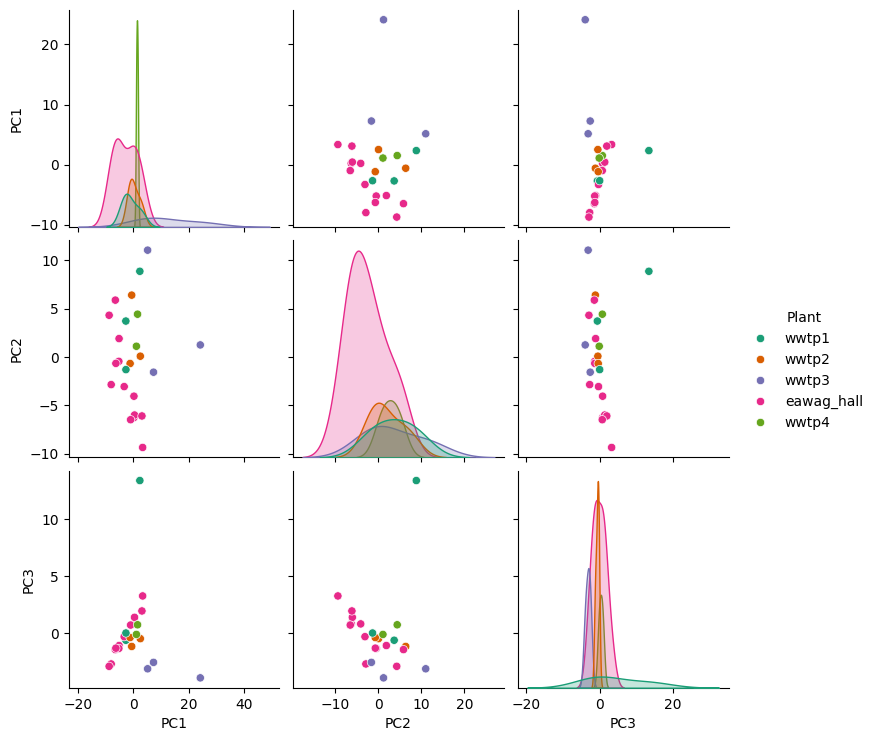

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Isolate spectral data based on your specific dataframe structure
# Columns 23 onwards are your wavelengths
X = spectra_A_df.iloc[:, 23:].values
y = spectra_A_df['sampling_location']

# 2. Preprocessing: Standard Normal Variate (SNV)
# This centers and scales each row independently to focus purely on spectral shape.
X_snv = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

# 3. Standardization (Scaling across features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_snv)

# Create a DF with the first 4 or 5 PCs
pca_full = PCA(n_components=4)
X_pca_full = pca_full.fit_transform(X_scaled)
pca_df_full = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(4)])
pca_df_full['Plant'] = y.values

# Generate a pairplot for the first 4 PCs
sns.pairplot(pca_df_full, vars=['PC1', 'PC2', 'PC3'], hue='Plant', palette='Dark2', diag_kind='kde')
plt.show()

In [99]:

import plotly.express as px


# 1. Use the PCA results you already calculated (X_pca_full)
# We will create a clean dataframe for the interactive plot
df_3d = pd.DataFrame(X_pca_full[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_3d['Plant'] = y.values

# 2. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Plant',
    symbol='Plant', # Different shapes for different plants
    opacity=0.7,
    title='Interactive 3D PCA: Wastewater Spectra Comparison',
    labels={
        'PC1': f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca_full.explained_variance_ratio_[2]*100:.1f}%)'
    }
)

# 3. Enhance the layout
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

# Show the plot
fig.show()